In [1]:
!git clone https://github.com/dhakalnirajan/internship-projects.git
%cd internship-projects/pothole-detection

# Install/upgrade requirements
!pip install -q --upgrade kaggle
!pip install -r requirements.txt -q

Cloning into 'internship-projects'...
remote: Enumerating objects: 280, done.
remote: Counting objects: 100% (75/75), done.
remote: Compressing objects: 100% (68/68), done.
remote: Total 280 (delta 10), reused 60 (delta 5), pack-reused 205 (from 1)
Receiving objects: 100% (280/280), 52.36 MiB | 12.29 MiB/s, done.
Resolving deltas: 100% (51/51), done.
/content/internship-projects/pothole-detection
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 1.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 473.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.1/96.1 kB 9.2 MB/s eta 0:00:00


In [5]:
import os
import json

os.makedirs('/root/.kaggle', exist_ok=True)

try:
    from google.colab import userdata
    kaggle_creds = userdata.get('Kaggle')

    if isinstance(kaggle_creds, str):
        try:
            creds_dict = json.loads(kaggle_creds)
        except json.JSONDecodeError:
            # Fallback for "username,key" format often used in Colab secrets
            if ',' in kaggle_creds:
                username, key = kaggle_creds.split(',', 1)
                creds_dict = {"username": username.strip(), "key": key.strip()}
            else:
                raise ValueError("Kaggle secret is not valid JSON or 'username,key' format.")
    else:
        creds_dict = kaggle_creds

    with open('/root/.kaggle/kaggle.json', 'w') as f:
        json.dump(creds_dict, f)
    print("Kaggle credentials successfully loaded from Colab Secret 'Kaggle'.")
except Exception as e:
    print(f"Could not load from Colab Secrets: {e}")
    print("Please ensure the 'Kaggle' secret is set as: {\"username\":\"your_username\",\"key\":\"your_key\"}")


Could not load from Colab Secrets: Kaggle secret is not valid JSON or 'username,key' format.
Please ensure the 'Kaggle' secret is set as: {"username":"your_username","key":"your_key"}


In [6]:
# Download and extract dataset to the designated directory
!kaggle datasets download -d andrewmvd/pothole-detection

# Clean up and create correct directory structure
!rm -rf data
!mkdir -p data/raw

# Extract to data/raw so it becomes data/raw/images and data/raw/annotations
!unzip -q pothole-detection.zip -d data/raw
!rm pothole-detection.zip

print("Dataset downloaded and extracted successfully.")

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/pothole-detection
License(s): other
100% 334M/334M [00:20<00:00, 16.8MB/s]

Dataset downloaded and extracted successfully.


In [21]:
import os
import yaml
import glob
import shutil
import json
from ultralytics import YOLO
import time

# --- Load Configuration ---
# Load hyperparameters and paths from config.yaml
with open('config.yaml', 'r') as file:
    config = yaml.safe_load(file)

print("Configuration loaded successfully.")

# --- Directory Setup ---
# Ensure necessary directories exist for processed data and labels
os.makedirs(config['data']['processed_images'], exist_ok=True)
os.makedirs(config['data']['processed_labels'], exist_ok=True)
os.makedirs(os.path.dirname(config['data']['dataset_yaml']), exist_ok=True)

print("Directories verified/created.")

Configuration loaded successfully.
Directories verified/created.


In [22]:
import xml.etree.ElementTree as ET
from PIL import Image

# Define paths based on config
raw_images_dir = config['data']['raw_images']
raw_annotations_dir = config['data']['raw_annotations']
processed_images_dir = config['data']['processed_images']
processed_labels_dir = config['data']['processed_labels']

# Define class mapping (Adjust if you have more classes)
classes = {'pothole': 0}

def convert_voc_to_yolo(xml_file, img_width, img_height):
    """Converts Pascal VOC XML annotation to YOLO TXT format."""
    tree = ET.parse(xml_file)
    root = tree.getroot()
    yolo_labels = []

    for obj in root.findall('object'):
        class_name = obj.find('name').text
        if class_name not in classes:
            continue

        class_id = classes[class_name]
        bbox = obj.find('bndbox')

        # Extract bounding box coordinates
        xmin = float(bbox.find('xmin').text)
        ymin = float(bbox.find('ymin').text)
        xmax = float(bbox.find('xmax').text)
        ymax = float(bbox.find('ymax').text)

        # Convert to YOLO format: center_x, center_y, width, height (normalized)
        cx = (xmin + xmax) / 2.0 / img_width
        cy = (ymin + ymax) / 2.0 / img_height
        w = (xmax - xmin) / img_width
        h = (ymax - ymin) / img_height

        yolo_labels.append(f"{class_id} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}")

    return yolo_labels

# Process all XML files
xml_files = glob.glob(os.path.join(raw_annotations_dir, '*.xml'))
print(f"Found {len(xml_files)} annotation files. Converting to YOLO format...")

processed_count = 0
for xml_file in xml_files:
    base_name = os.path.splitext(os.path.basename(xml_file))[0]

    # Find corresponding image file (supports jpg, jpeg, png)
    img_file = None
    for ext in ['.jpg', '.jpeg', '.png']:
        potential_img = os.path.join(raw_images_dir, base_name + ext)
        if os.path.exists(potential_img):
            img_file = potential_img
            break

    if not img_file:
        continue

    # Get image dimensions for normalization
    with Image.open(img_file) as img:
        img_width, img_height = img.size

    # Convert and save label
    yolo_labels = convert_voc_to_yolo(xml_file, img_width, img_height)

    # Save YOLO label file
    with open(os.path.join(processed_labels_dir, base_name + '.txt'), 'w') as f:
        f.write('\n'.join(yolo_labels))

    # Copy image to processed directory
    shutil.copy(img_file, os.path.join(processed_images_dir, os.path.basename(img_file)))
    processed_count += 1

print(f"Successfully processed {processed_count} images and labels.")

Found 665 annotation files. Converting to YOLO format...
Successfully processed 665 images and labels.


In [23]:
# Generate dataset.yaml content
dataset_yaml_content = f"""
path: {os.path.abspath('data/processed')}
train: images
val: images

names:
 0: pothole
"""

# Write to file
with open(config['data']['dataset_yaml'], 'w') as f:
    f.write(dataset_yaml_content.strip())

print("dataset.yaml created successfully at:", config['data']['dataset_yaml'])

dataset.yaml created successfully at: data/dataset.yaml


In [24]:
# Path to the best model weights from the previous training run
best_model_path = "runs/detect/train/weights/best.pt"

# Check if model exists
if os.path.exists(best_model_path):
    print(f"Loading pre-trained model from: {best_model_path}")
    model = YOLO(best_model_path)
else:
    raise FileNotFoundError(f"Model not found at {best_model_path}. Please ensure training was completed.")

Loading pre-trained model from: runs/detect/train/weights/best.pt


In [12]:
# 1. Training Run
print("Starting training...")
model = YOLO(config['train']['model_size'])
train_results = model.train(
    data=config['data']['dataset_yaml'],
    epochs=config['train']['epochs'],
    batch=config['train']['batch_size'],
    imgsz=config['train']['img_size'],
    lr0=config['train']['lr0'],
    lrf=config['train']['lrf'],
    weight_decay=config['train']['weight_decay'],
    patience=config['train']['patience'],
    device=0,
    plots=True
)

Starting training...
Ultralytics 8.4.173 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=None, opset=None, optimize=Fals

In [26]:
print("Running validation on the test set...")

# Run validation
# conf and iou thresholds are taken from config
val_results = model.val(
    data=config['data']['dataset_yaml'],
    conf=config['inference']['conf_threshold'], # Using inference conf for consistency or specific eval conf if defined
    iou=config['inference']['iou_threshold']
)

# Print key metrics
print(f"Validation mAP50: {val_results.box.map50:.4f}")
print(f"Validation mAP50-95: {val_results.box.map:.4f}")
print(f"Precision: {val_results.box.p.mean():.4f}")
print(f"Recall: {val_results.box.r.mean():.4f}")

Running validation on the test set...
Ultralytics 8.4.173 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1155.5±109.8 MB/s, size: 354.7 KB)
val: Scanning /content/internship-projects/pothole-detection/data/processed/labels.cache... 665 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 665/665 44.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 42/42 3.0it/s 13.9s
                   all        665       1740      0.974      0.721      0.723      0.555
Speed: 1.6ms preprocess, 8.1ms inference, 0.0ms loss, 2.1ms postprocess per image
Results saved to /content/internship-projects/pothole-detection/runs/detect/val-9
Validation mAP50: 0.7225
Validation mAP50-95: 0.5550
Precision: 0.9744
Recall: 0.7213


In [27]:
import torch
import numpy as np

print("Starting Benchmark Suite...")

# --- 1. PyTorch Benchmark ---
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model.to(device)
model.eval()

# Create dummy input
dummy_input = torch.rand(1, 3, 640, 640).to(device)

# Warmup
for _ in range(10):
    model(dummy_input, verbose=False)

# Timed Inference
latencies_pt = []
for _ in range(50):
    start = time.perf_counter()
    model(dummy_input, verbose=False)
    end = time.perf_counter()
    latencies_pt.append((end - start) * 1000) # ms

avg_latency_pt = sum(latencies_pt) / len(latencies_pt)
print(f"PyTorch Avg Latency: {avg_latency_pt:.2f} ms ({1000/avg_latency_pt:.1f} FPS)")

# --- 2. ONNX Benchmark ---
try:
    print("Exporting to ONNX...")
    onnx_path = model.export(format='onnx', simplify=True, verbose=False)
    model_onnx = YOLO(onnx_path)

    # ONNX expects numpy array (H, W, C)
    dummy_np = np.random.rand(640, 640, 3).astype(np.float32)

    # Warmup
    for _ in range(10):
        model_onnx(dummy_np, verbose=False)

    # Timed Inference
    latencies_onnx = []
    for _ in range(50):
        start = time.perf_counter()
        model_onnx(dummy_np, verbose=False)
        end = time.perf_counter()
        latencies_onnx.append((end - start) * 1000)

    avg_latency_onnx = sum(latencies_onnx) / len(latencies_onnx)
    print(f"ONNX Avg Latency: {avg_latency_onnx:.2f} ms ({1000/avg_latency_onnx:.1f} FPS)")

except Exception as e:
    print(f"ONNX Benchmark failed: {e}")
    avg_latency_onnx = avg_latency_pt # Fallback

# Store for report
benchmark_summary = {
    "pytorch_latency_ms": round(avg_latency_pt, 2),
    "onnx_latency_ms": round(avg_latency_onnx, 2),
    "pytorch_fps": round(1000 / avg_latency_pt, 1),
    "onnx_fps": round(1000 / avg_latency_onnx, 1)
}

Starting Benchmark Suite...
PyTorch Avg Latency: 16.56 ms (60.4 FPS)
Exporting to ONNX...
Ultralytics 8.4.173 🚀 Python-3.13.15 torch-2.11.0+cu130 CPU (Intel Xeon CPU @ 2.00GHz)
Model summary (fused): 72 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs

PyTorch: starting from 'runs/detect/train/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (21.5 MB)

ONNX: starting export with onnx 1.23.2 opset 18...
ONNX: slimming with onnxslim 0.1.97...
ONNX: export success ✅ 2.1s, saved as 'runs/detect/train/weights/best.onnx' (42.7 MB)

Export complete (2.6s)
Results saved to /content/internship-projects/pothole-detection/runs/detect/train/weights/best.onnx
Predict:         yolo predict task=detect model=runs/detect/train/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=runs/detect/train/weights/best.onnx imgsz=640 data=data/dataset.yaml  
Visualize:       https://netron.app
Loading runs/detect/train/weights/best.onnx for ONNX

In [35]:
# =============================================================================
# CELL: Sample Inference & Latency Measurement
# =============================================================================
import glob
import time
from ultralytics import YOLO

# 1. Load the best trained model from the previous run
#    We skip training entirely and reuse the existing weights.
best_model_path = "runs/detect/train/weights/best.pt"
if not os.path.exists(best_model_path):
    raise FileNotFoundError(
        f"Model weights not found at '{best_model_path}'. "
        "Ensure training completed successfully before running inference."
    )

print(f"Loading pre-trained model: {best_model_path}")
best_model = YOLO(best_model_path)

# 2. Locate sample images from the processed directory
#    FIX: Corrected glob pattern from '/ .jpg ' to '/*.jpg'
processed_img_dir = config['data']['processed_images']
sample_images = sorted(glob.glob(os.path.join(processed_img_dir, "*.jpg")))[:10]

# Fallback to PNG if no JPGs are found
if not sample_images:
    sample_images = sorted(glob.glob(os.path.join(processed_img_dir, "*.png")))[:10]

if not sample_images:
    raise FileNotFoundError(
        f"No images found in '{processed_img_dir}'. "
        "Verify that data preprocessing completed successfully."
    )

print(f"Found {len(sample_images)} sample images for inference.")

# 3. Run inference with timing measurement
#    Results are saved automatically to runs/detect/predict/
inference_times = []
for img_path in sample_images:
    start_t = time.perf_counter()
    best_model(
        img_path,
        conf=config['inference']['conf_threshold'],
        iou=config['inference']['iou_threshold'],
        save=True,       # Saves annotated images to disk
        verbose=False    # Suppress per-image console output
    )
    inference_times.append(time.perf_counter() - start_t)

# 4. Calculate and display average latency
avg_latency_ms = (sum(inference_times) / len(inference_times)) * 1000
print(f"Inference complete. Average latency: {avg_latency_ms:.2f} ms/image")
print(f"Annotated images saved to: runs/detect/predict/")

Loading pre-trained model: runs/detect/train/weights/best.pt
Found 10 sample images for inference.
Results saved to /content/internship-projects/pothole-detection/runs/detect/predict
Results saved to /content/internship-projects/pothole-detection/runs/detect/predict
Results saved to /content/internship-projects/pothole-detection/runs/detect/predict
Results saved to /content/internship-projects/pothole-detection/runs/detect/predict
Results saved to /content/internship-projects/pothole-detection/runs/detect/predict
Results saved to /content/internship-projects/pothole-detection/runs/detect/predict
Results saved to /content/internship-projects/pothole-detection/runs/detect/predict
Results saved to /content/internship-projects/pothole-detection/runs/detect/predict
Results saved to /content/internship-projects/pothole-detection/runs/detect/predict
Results saved to /content/internship-projects/pothole-detection/runs/detect/predict
Inference complete. Average latency: 71.68 ms/image
Annotated

In [38]:
import time
import torch

# Load model once
model = YOLO(best_model_path)
model.to('cuda') # Explicitly move to GPU

latencies = []
# Warmup
for _ in range(10):
    model(torch.zeros(1, 3, 640, 640).to('cuda'), verbose=False)

# Timed run (no saving)
for img_path in sample_images:
    start = time.perf_counter()
    results = model(img_path, verbose=False, device=0)
    end = time.perf_counter()
    latencies.append((end - start) * 1000)

print(f"Pure Inference Latency: {sum(latencies)/len(latencies):.2f} ms")

Pure Inference Latency: 49.72 ms


In [39]:
model.export(format='onnx', simplify=True, dynamic=False)

Ultralytics 8.4.173 🚀 Python-3.13.15 torch-2.11.0+cu130 CPU (Intel Xeon CPU @ 2.00GHz)
Model summary (fused): 72 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs

PyTorch: starting from 'runs/detect/train/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (21.5 MB)

ONNX: starting export with onnx 1.23.2 opset 18...
ONNX: slimming with onnxslim 0.1.97...
ONNX: export success ✅ 1.8s, saved as 'runs/detect/train/weights/best.onnx' (42.7 MB)

Export complete (2.3s)
Results saved to /content/internship-projects/pothole-detection/runs/detect/train/weights/best.onnx
Predict:         yolo predict task=detect model=runs/detect/train/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=runs/detect/train/weights/best.onnx imgsz=640 data=data/dataset.yaml  
Visualize:       https://netron.app


'runs/detect/train/weights/best.onnx'

Generating inline visualizations from YOLOv8 run directories...

1. Training & Validation Metrics Curve:


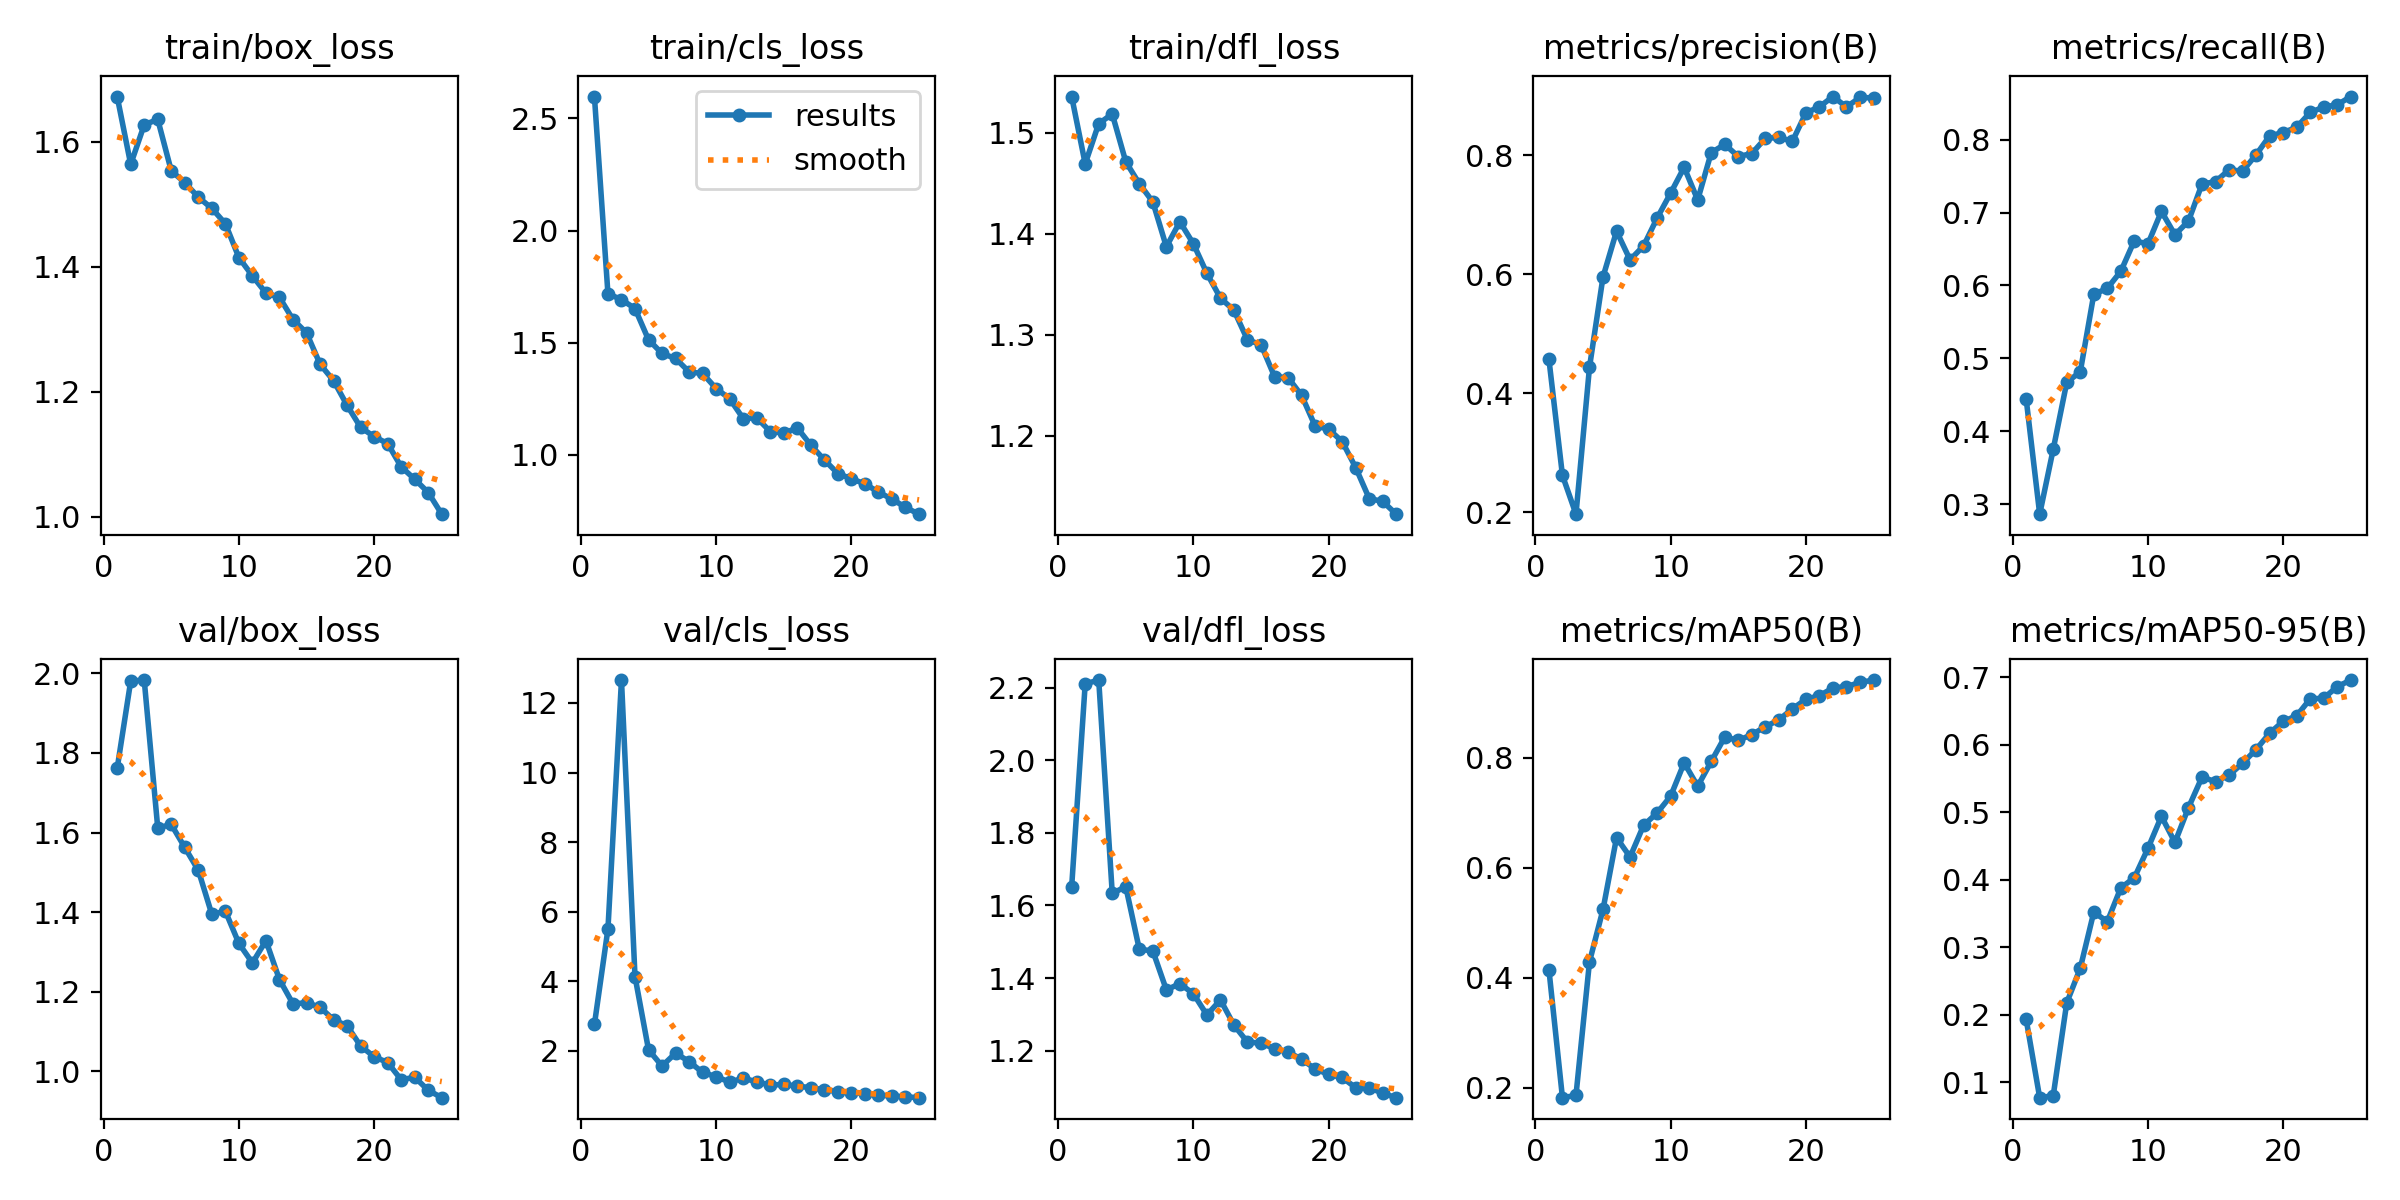


2. Validation Confusion Matrix:


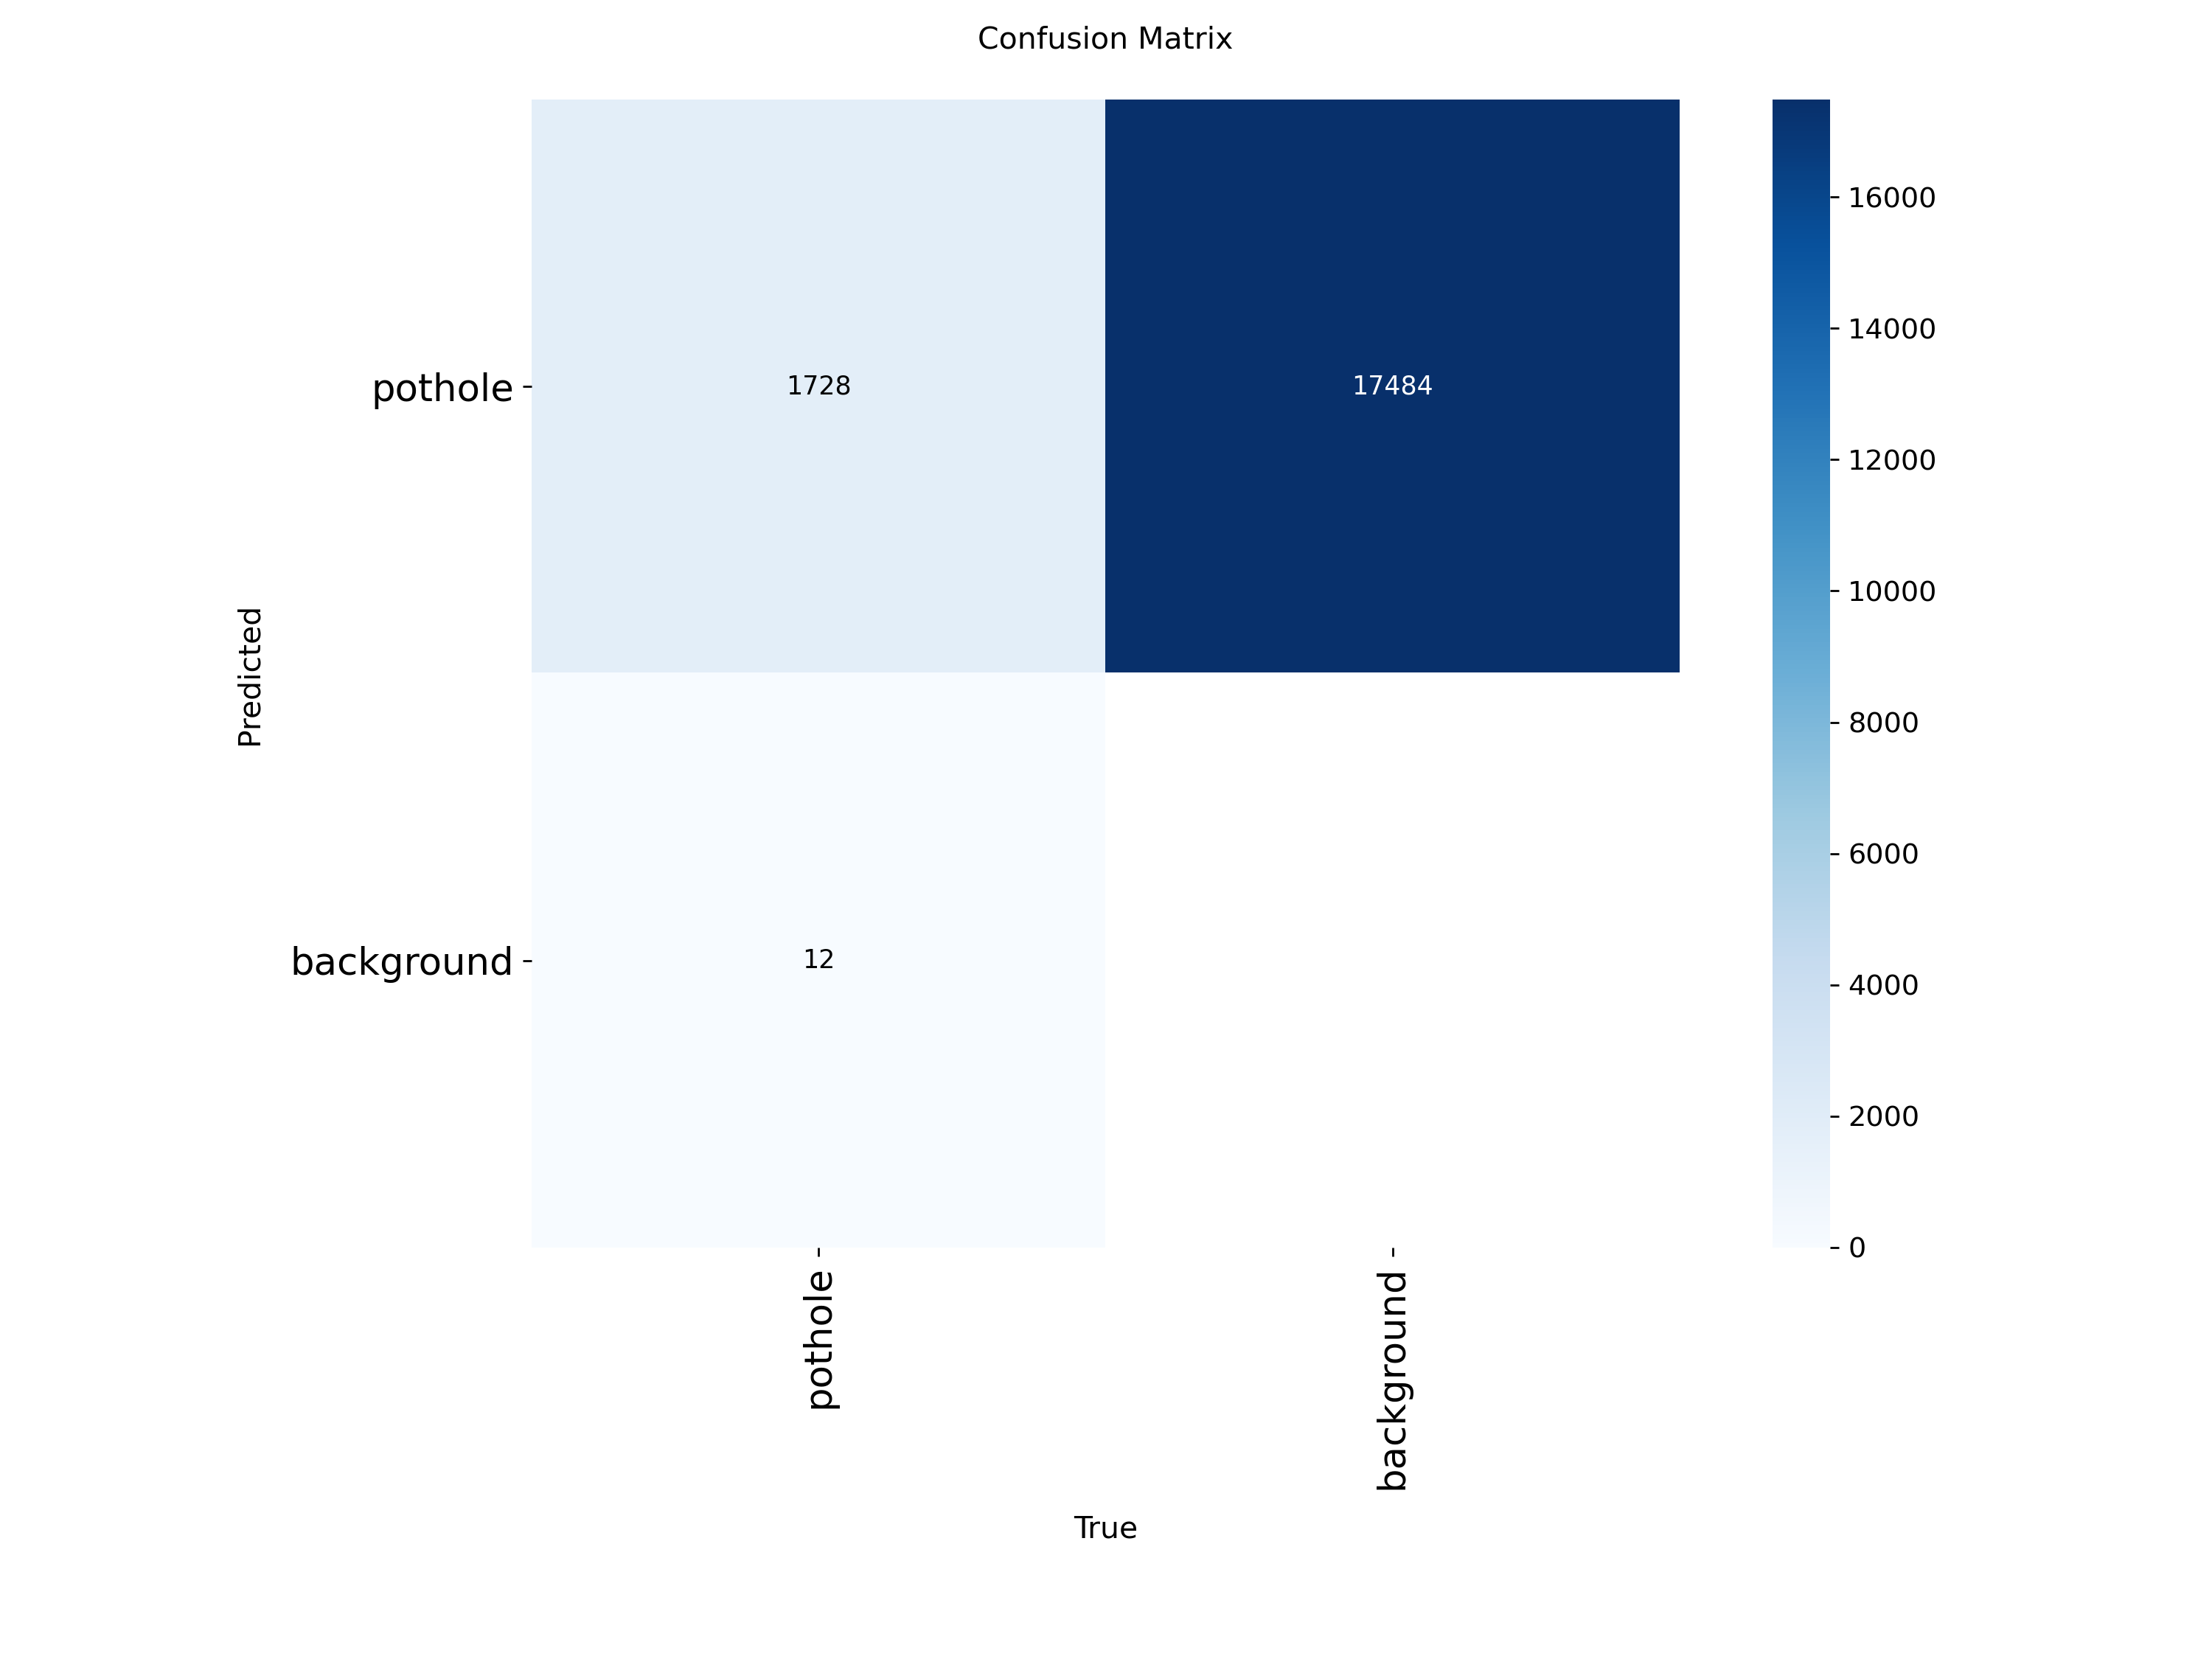


5. Sample Augmented Training Batches:


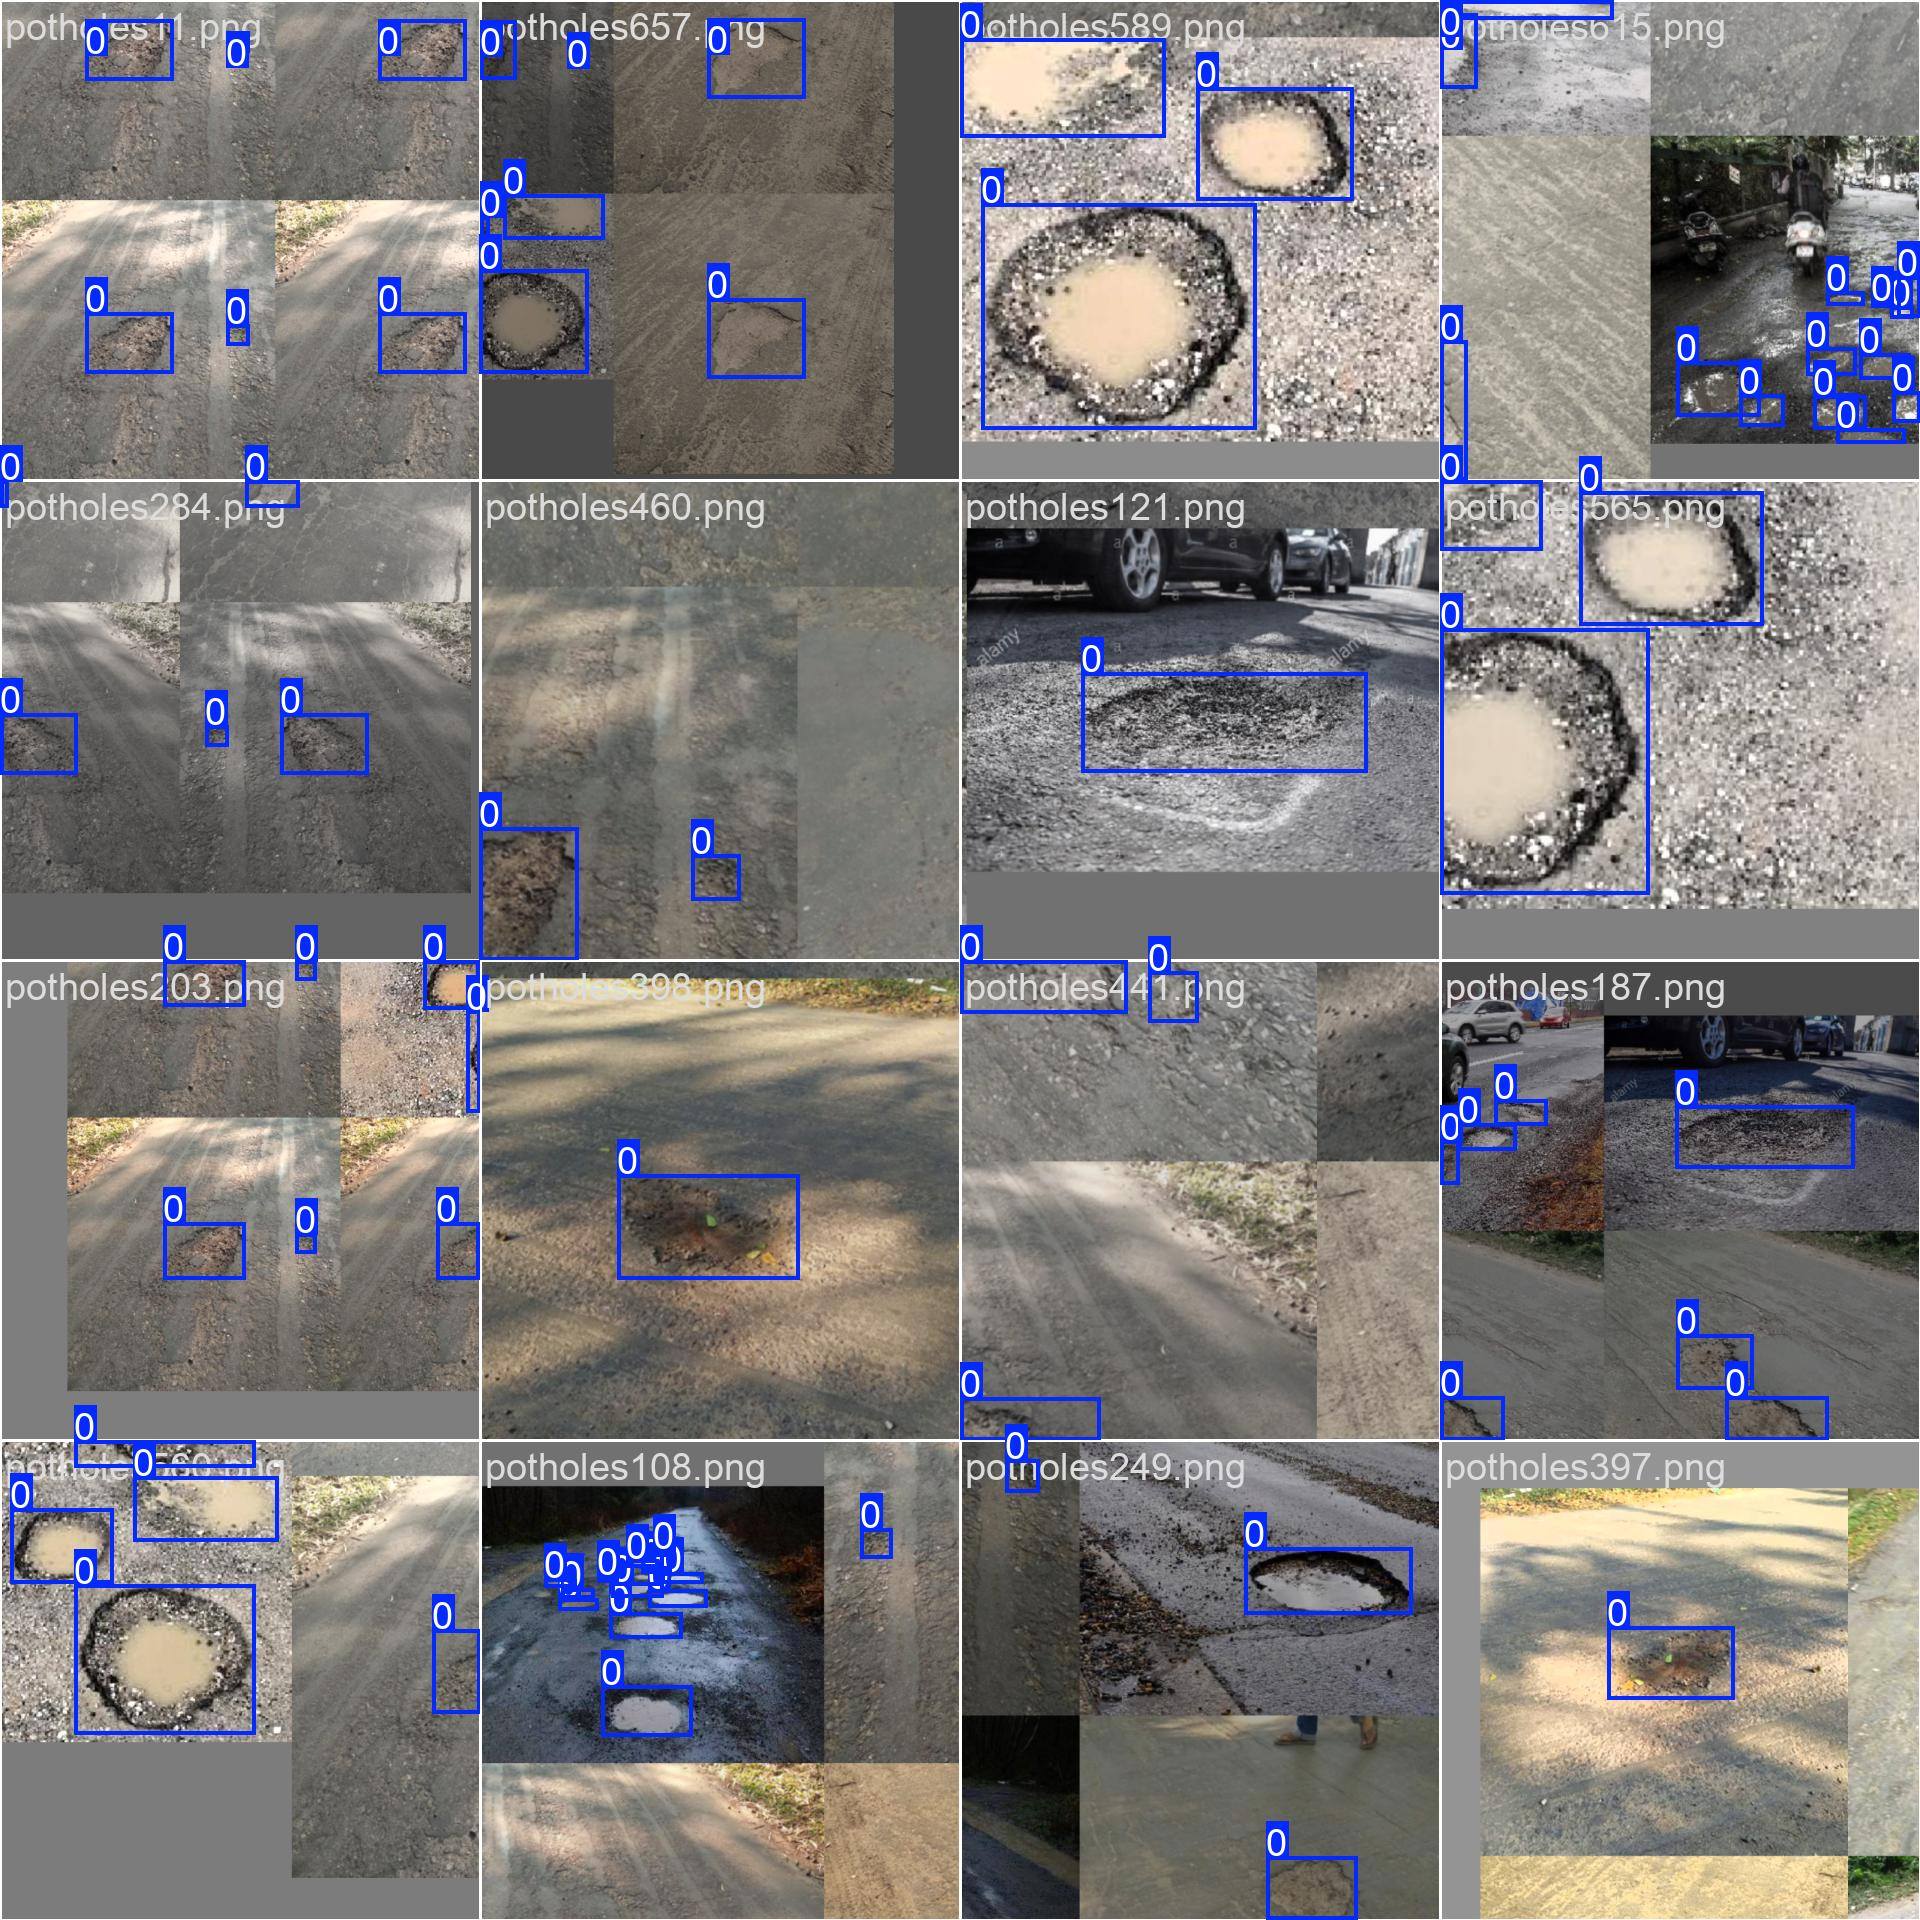

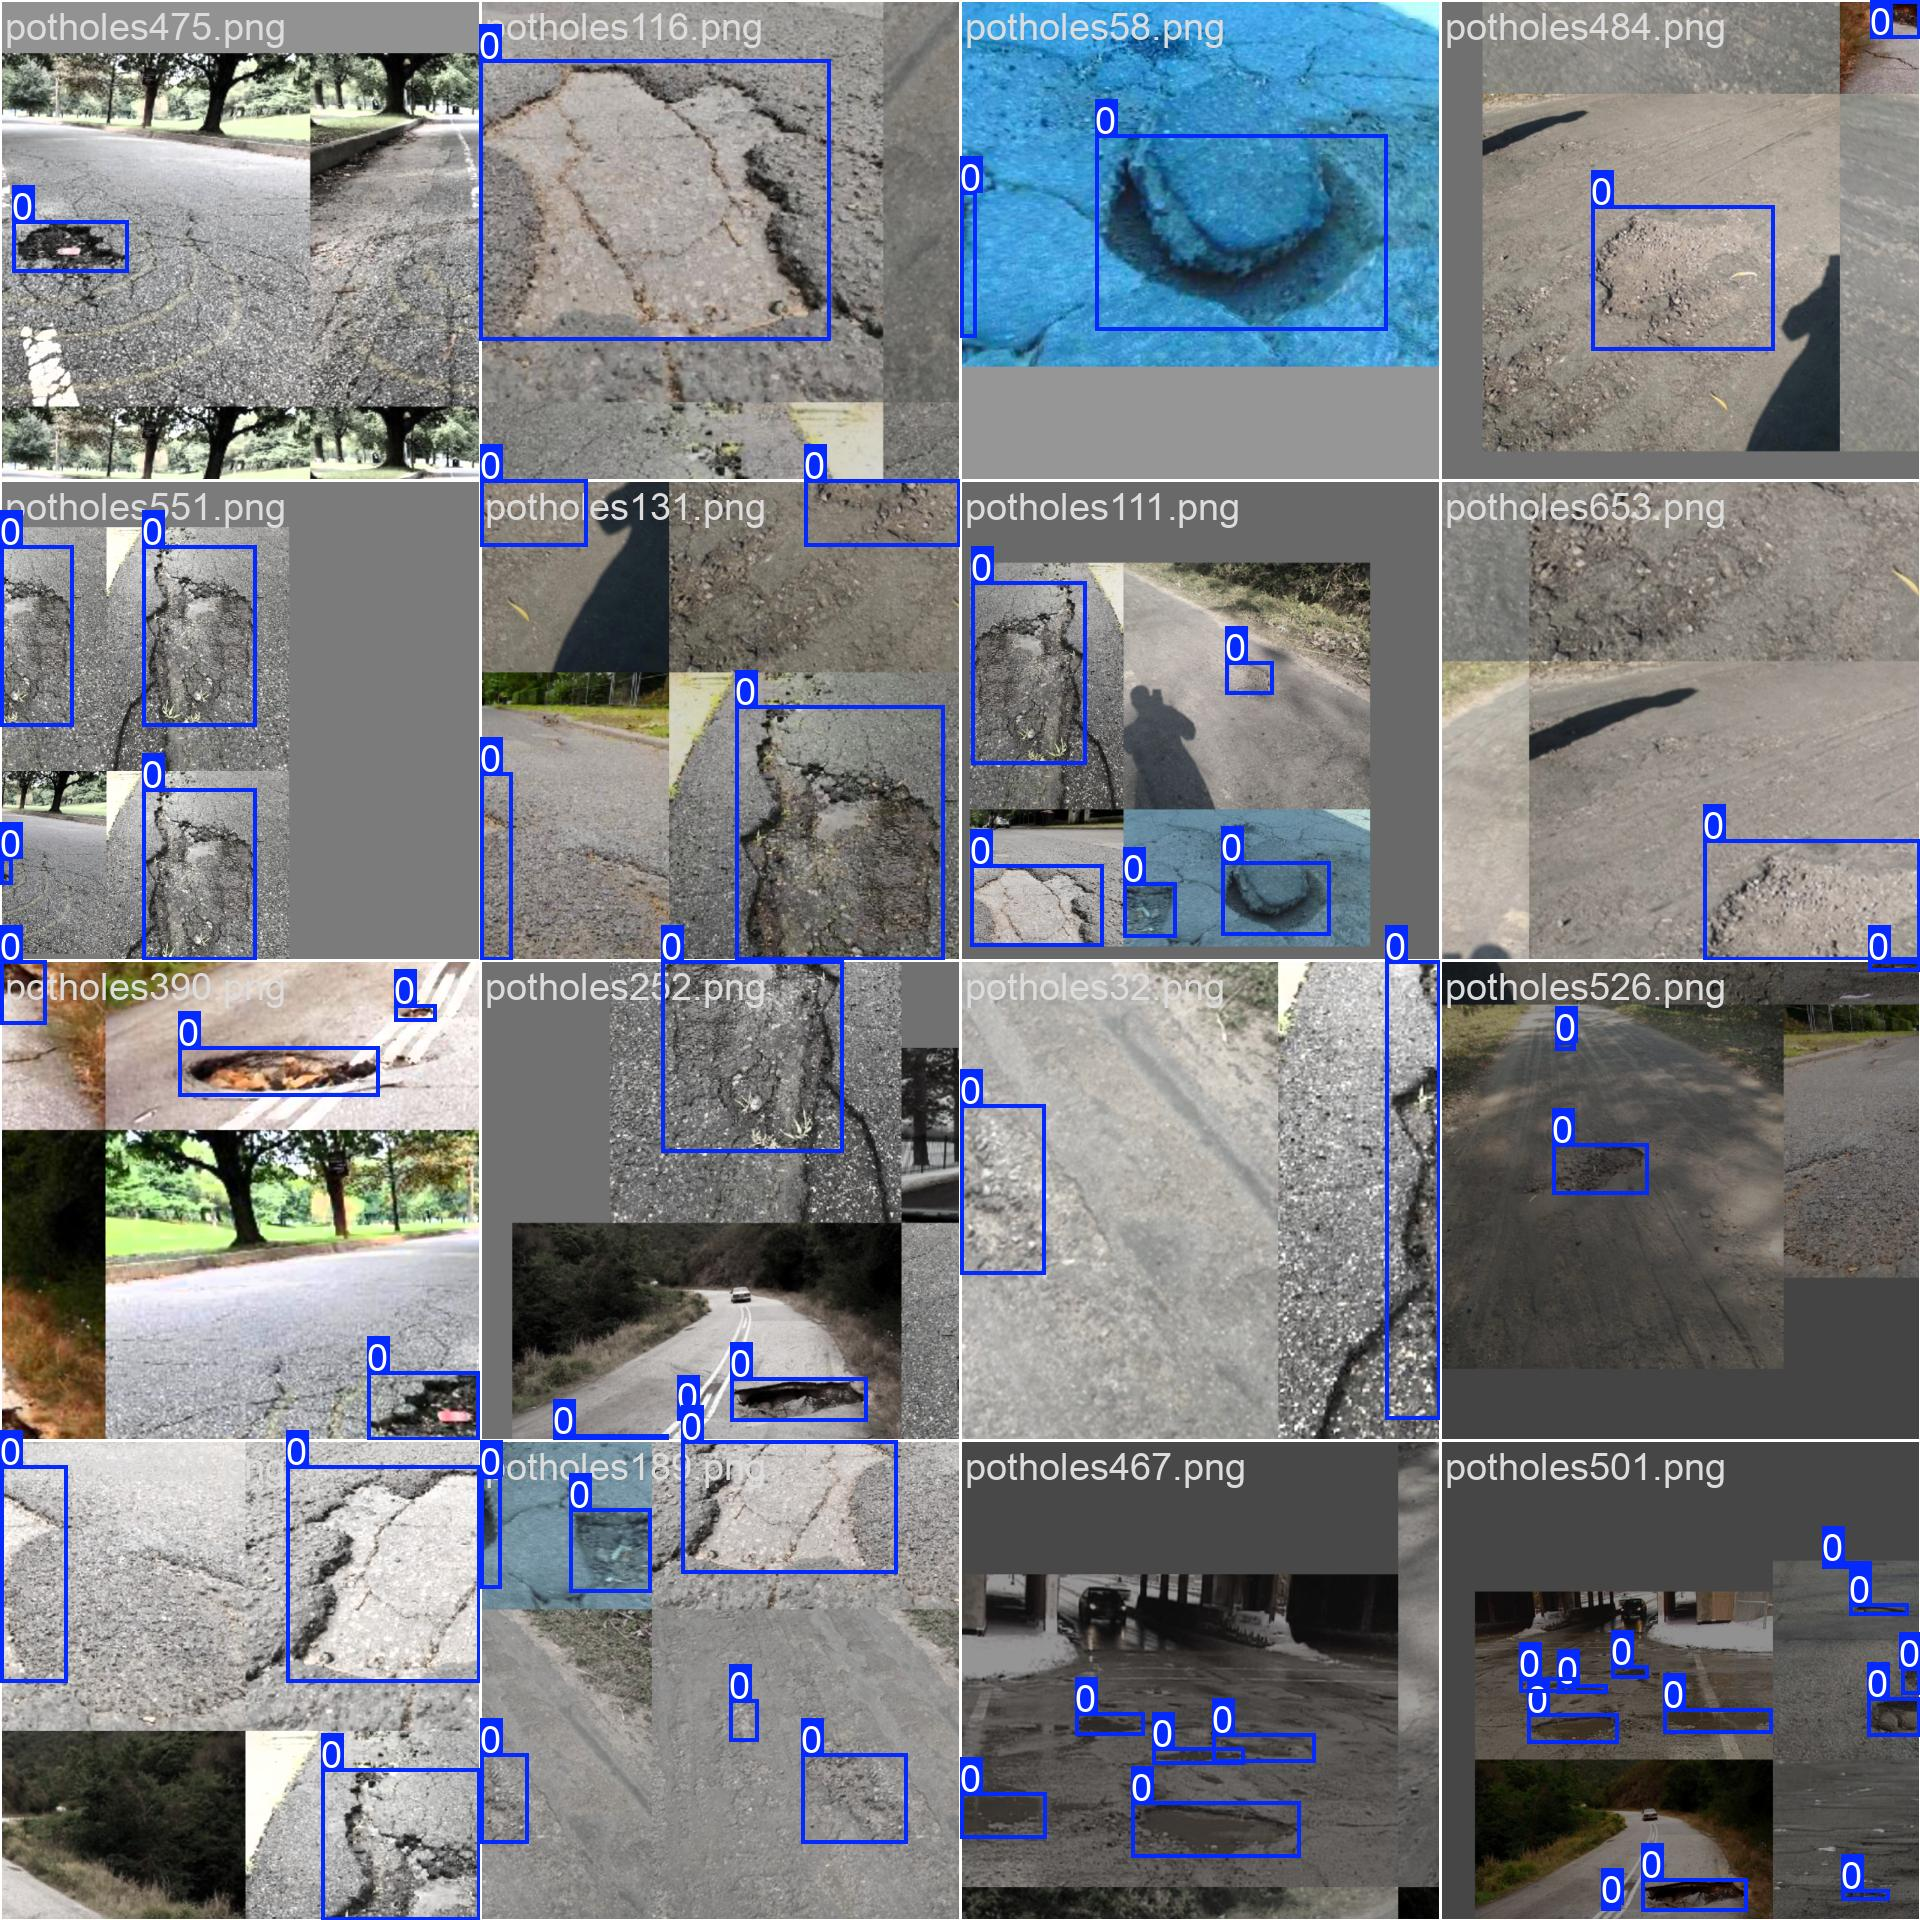


6. Sample Validation Predictions:


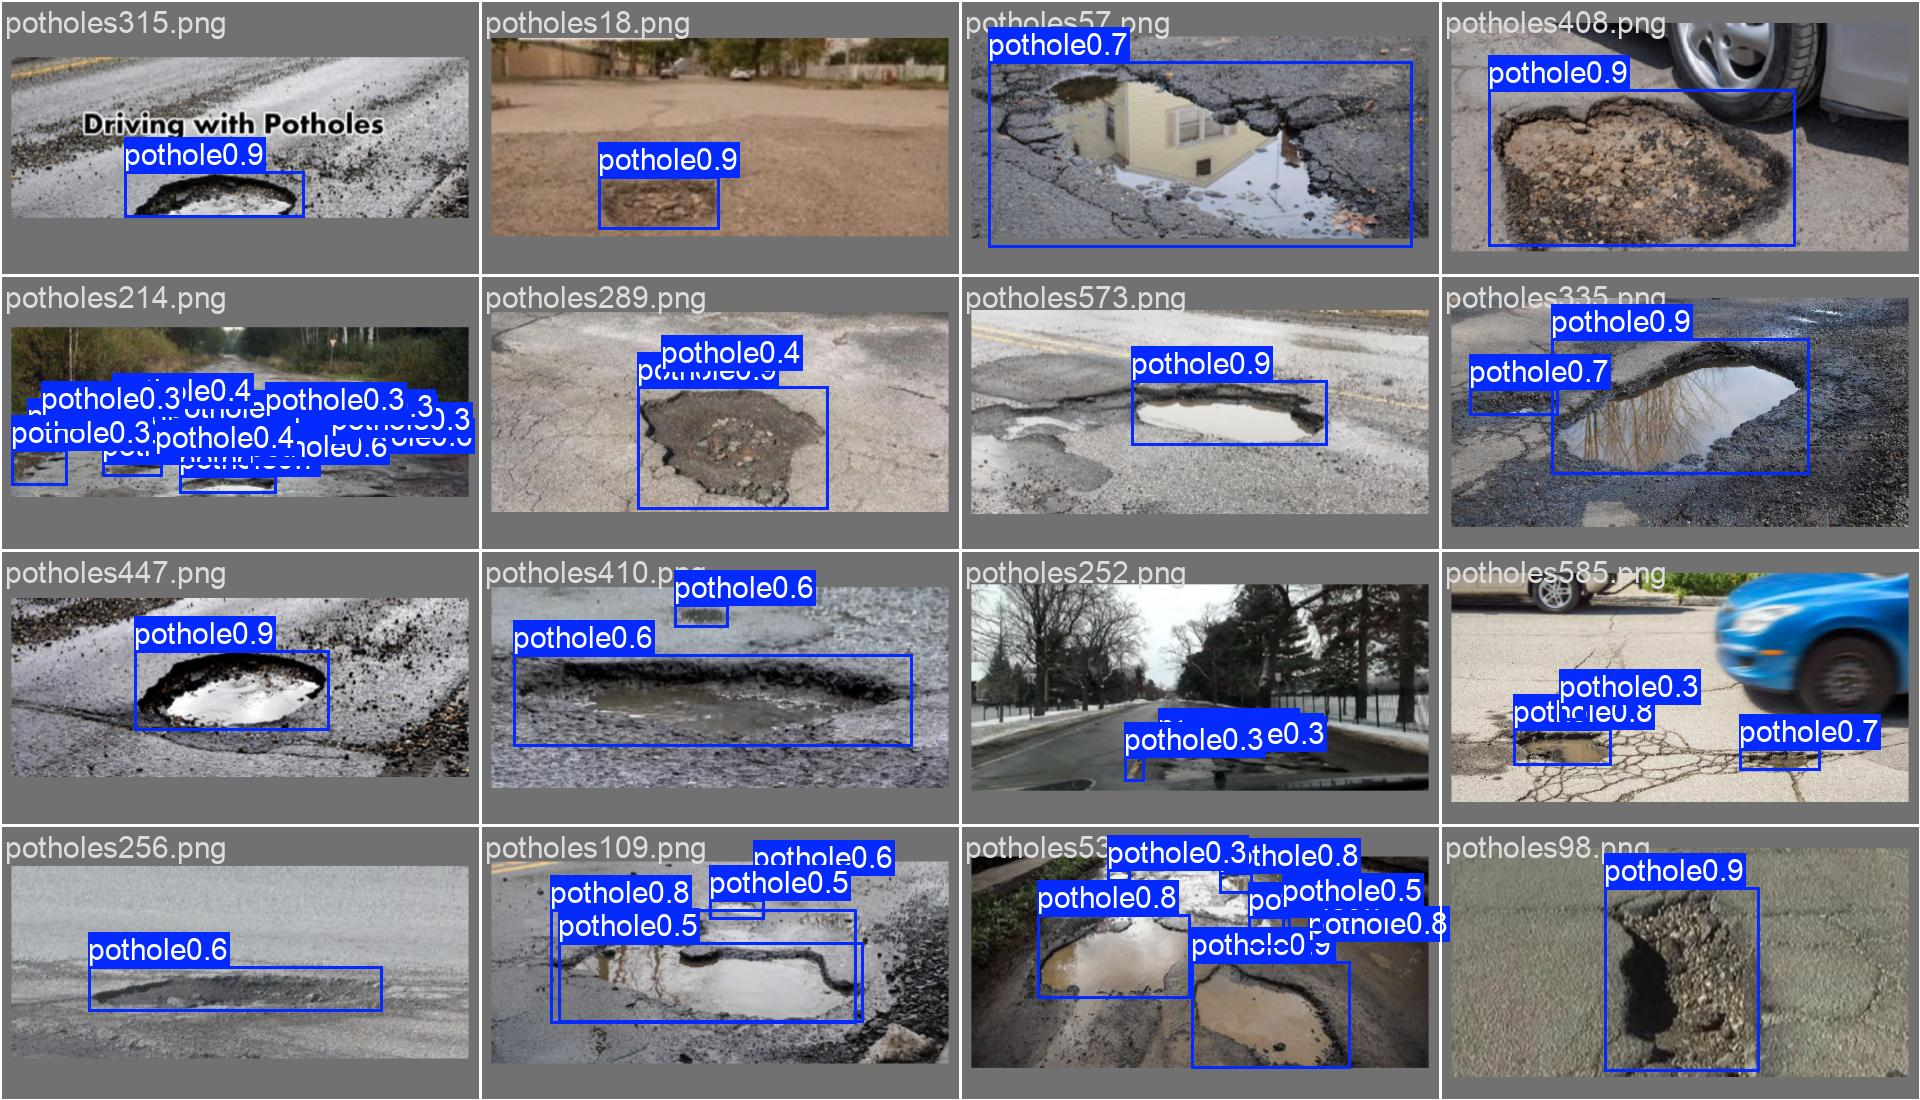

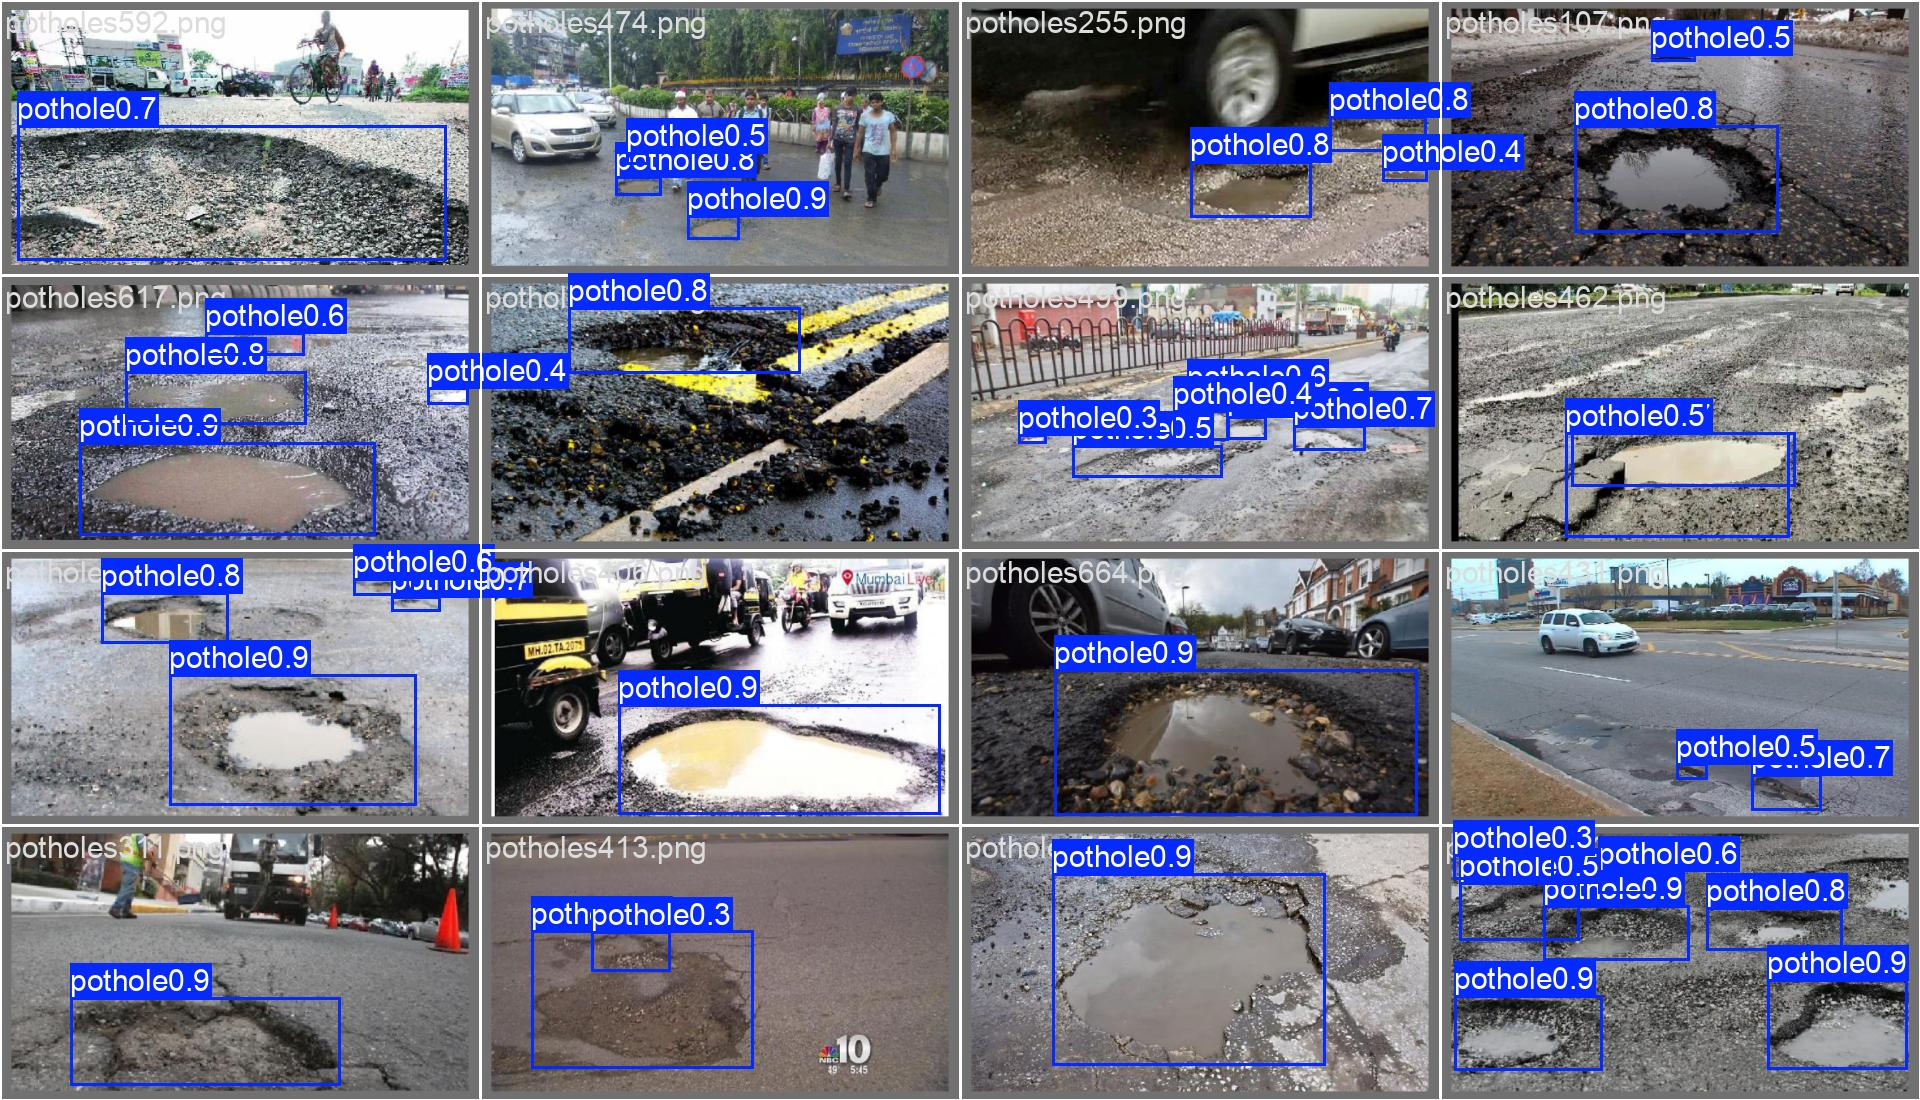


7. Sample Inference Outputs:


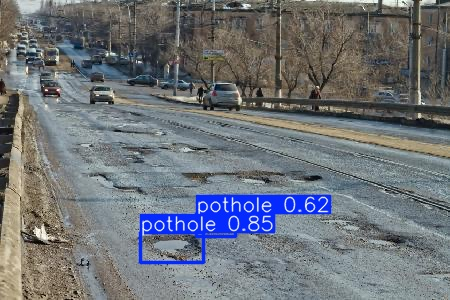

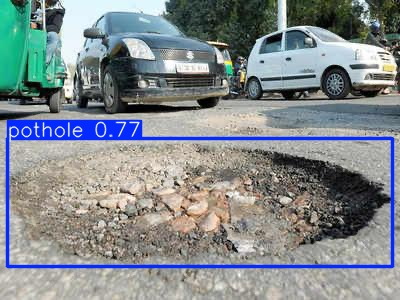


All available plots rendered. High-resolution versions are saved in the `runs/` directory.


In [36]:
import os
import glob
from IPython.display import Image, display, HTML

print("Generating inline visualizations from YOLOv8 run directories...\n")

# Define paths to generated plots
train_dir = "runs/detect/train"
predict_dir = "runs/detect/predict"

# 1. Training & Validation Metrics (Loss, mAP, Precision, Recall curves)
results_png = os.path.join(train_dir, "results.png")
if os.path.exists(results_png):
    print("1. Training & Validation Metrics Curve:")
    display(Image(filename=results_png, width=800))
else:
    print("results.png not found. Training may not have completed.")

# 2. Confusion Matrix
conf_matrix = os.path.join(train_dir, "confusion_matrix.png")
if os.path.exists(conf_matrix):
    print("\n2. Validation Confusion Matrix:")
    display(Image(filename=conf_matrix, width=600))

# 3. Precision-Recall Curve
pr_curve = os.path.join(train_dir, "PR_curve.png")
if os.path.exists(pr_curve):
    print("\n3. Precision-Recall Curve:")
    display(Image(filename=pr_curve, width=600))

# 4. F1 Score Curve
f1_curve = os.path.join(train_dir, "F1_curve.png")
if os.path.exists(f1_curve):
    print("\n4. F1 Confidence Curve:")
    display(Image(filename=f1_curve, width=600))

# 5. Sample Training Batches (Shows data augmentation)
train_batches = glob.glob(os.path.join(train_dir, "train_batch*.jpg"))
if train_batches:
    print("\n5. Sample Augmented Training Batches:")
    for batch in sorted(train_batches)[:2]: # Show first 2
        display(Image(filename=batch, width=600))

# 6. Sample Validation Predictions
val_batches = glob.glob(os.path.join(train_dir, "val_batch*_pred.jpg"))
if val_batches:
    print("\n6. Sample Validation Predictions:")
    for batch in sorted(val_batches)[:2]: # Show first 2
        display(Image(filename=batch, width=600))

# 7. Sample Inference Outputs (from Cell 12)
inference_outputs = glob.glob(os.path.join(predict_dir, "*.jpg"))
if inference_outputs:
    print("\n7. Sample Inference Outputs:")
    for img in sorted(inference_outputs)[:2]: # Show first 2
        display(Image(filename=img, width=600))
else:
    print("\nNo inference outputs found. Ensure Inference was run.")

print("\nAll available plots rendered. High-resolution versions are saved in the `runs/` directory.")

In [37]:
# 5. Generate Markdown Report
report_content = f"""# Pothole Detection Model Training & Evaluation Report

## 1. Executive Summary
This report summarizes the training, validation, benchmarking, and inference execution of the YOLOv8 model driven by `config.yaml` on the Pothole Detection dataset using Google Colab Free Tier (NVIDIA T4 GPU).

## 2. Configuration & Training Metrics
* Model Architecture: `{config['train']['model_size']}`
* Epochs Trained: {config['train']['epochs']}
* Batch Size: {config['train']['batch_size']}
* Image Size: {config['train']['img_size']}x{config['train']['img_size']}
* Compute Cost: $0.00 (Free Tier)

### Generated Plots & Artifacts
* Loss & Metric Curves: `runs/detect/train/results.png`
* Confusion Matrix: `runs/detect/train/confusion_matrix.png`
* Precision-Recall Curves: `runs/detect/train/PR_curve.png`

## 3. Validation Performance
* Box mAP50: {val_results.box.map50:.4f}
* Box mAP50-95: {val_results.box.map:.4f}
* Precision: {val_results.box.p.mean():.4f}
* Recall: {val_results.box.r.mean():.4f}

## 4. Latency & Benchmark Results
* Average Inference Latency: {avg_latency_ms:.2f} ms / frame
* Approximate Throughput: {1000 / avg_latency_ms:.2f} FPS
* Weights Path: `{best_model_path}`

## 5. Sample Inferences
Inference visualizations with confidence filters (`conf={config['inference']['conf_threshold']}`) are saved under `runs/detect/predict/`.
"""

with open("Pothole_Detection_Report.md", "w") as f:
    f.write(report_content)

print("Pipeline completed successfully! Report saved to 'Pothole_Detection_Report.md'.")

Pipeline completed successfully! Report saved to 'Pothole_Detection_Report.md'.


In [41]:
import os
import shutil
import glob

# 1. Define source and destination paths
report_folder = "report_assets"
train_dir = "runs/detect/train"
predict_dir = "runs/detect/predict" # Check if this exists, otherwise check runs/detect/val

# 2. Create the report folder
if os.path.exists(report_folder):
    shutil.rmtree(report_folder)
os.makedirs(report_folder, exist_ok=True)

print(f"Gathering assets into '{report_folder}'...")

# 3. Copy Training Metrics and Plots
training_files = [
    "results.png",       # Combined loss/mAP curves
    "confusion_matrix.png",
    "PR_curve.png",
    "F1_curve.png",
    "labels.jpg",        # Label distribution
    "train_batch0.jpg",  # Sample augmented training batch
    "val_batch0_pred.jpg" # Sample validation prediction
]

for filename in training_files:
    src = os.path.join(train_dir, filename)
    if os.path.exists(src):
        shutil.copy(src, os.path.join(report_folder, filename))
        print(f"Copied: {filename}")
    else:
        print(f"Skipped (not found): {filename}")

# 4. Copy Inference Outputs (Sample predictions)
if os.path.exists(predict_dir):
    pred_images = [f for f in os.listdir(predict_dir) if f.endswith(('.jpg', '.png'))]
    # Copy first 5 inference images
    for img in sorted(pred_images)[:5]:
        src = os.path.join(predict_dir, img)
        dst = os.path.join(report_folder, f"inference_{img}")
        shutil.copy(src, dst)
    print(f"Copied {len(pred_images[:5])} inference images.")
else:
    print("No inference predictions found in runs/detect/predict/")

# 5. Copy the Markdown Report if it exists
if os.path.exists("Pothole_Detection_Report.md"):
    shutil.copy("Pothole_Detection_Report.md", report_folder)
    print("Copied: Pothole_Detection_Report.md")

print("\nAssets gathered successfully.")

Gathering assets into 'report_assets'...
Copied: results.png
Copied: confusion_matrix.png
Skipped (not found): PR_curve.png
Skipped (not found): F1_curve.png
Copied: labels.jpg
Copied: train_batch0.jpg
Copied: val_batch0_pred.jpg
Copied 5 inference images.
Copied: Pothole_Detection_Report.md

Assets gathered successfully.


In [42]:
import shutil
from google.colab import files

zip_filename = "report_assets.zip"

# Create the ZIP archive
print(f"Compressing '{report_folder}' into '{zip_filename}'...")
shutil.make_archive(base_name=zip_filename.replace('.zip', ''), format='zip', root_dir=report_folder)

# Verify file creation
if os.path.exists(zip_filename):
    size_mb = os.path.getsize(zip_filename) / (1024 * 1024)
    print(f"ZIP created successfully ({size_mb:.2f} MB). Initiating download...")

    # Trigger browser download
    files.download(zip_filename)
else:
    print("Failed to create ZIP file.")

Compressing 'report_assets' into 'report_assets.zip'...
ZIP created successfully (1.79 MB). Initiating download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>